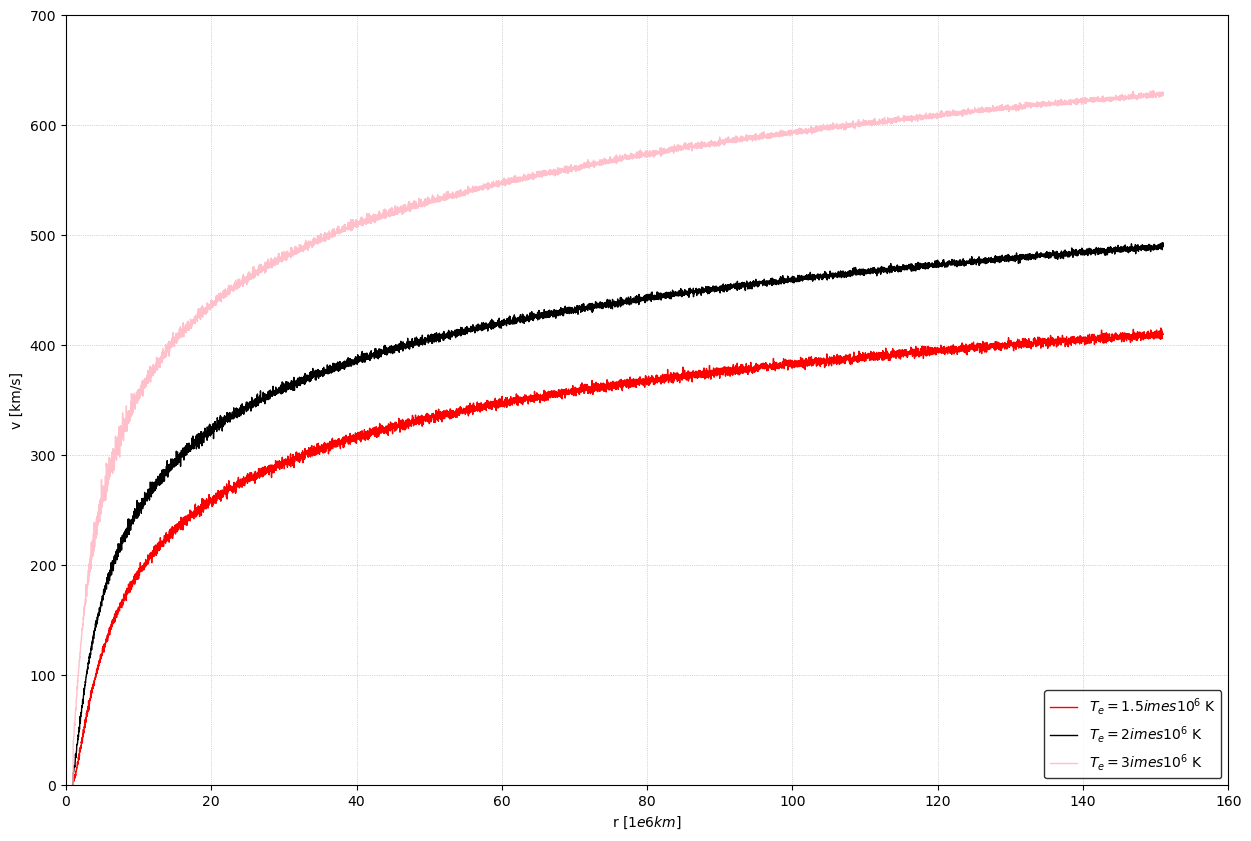

In [7]:
files=['data_SW_No1.dat','data_SW_No2.dat','data_SW_No3.dat']
labels=['$T_e = 1.5 \times 10^6$ K','$T_e = 2 \times 10^6$ K','$T_e = 3 \times 10^6$ K']
colors=['red','black','pink']
plt.figure(figsize=(15, 10))
for file,label,color in zip(files,labels,colors):
    data=np.loadtxt(file)
    r_meters=data[:,0]
    v_mps=data[:,1]
    v_km_s=v_mps/1000
    r_1e6km=r_meters/1e9
    plt.plot(r_1e6km,v_km_s,label=label,color=color,linewidth=1)
plt.xlabel('r [$1e6 km$]')
plt.ylabel('v [km/s]')
plt.legend(loc='lower right',frameon=True,edgecolor='black')
plt.grid(True,which='both',linestyle=':',linewidth=0.5)
plt.xlim(0,160)
plt.ylim(0,700)
plt.show()

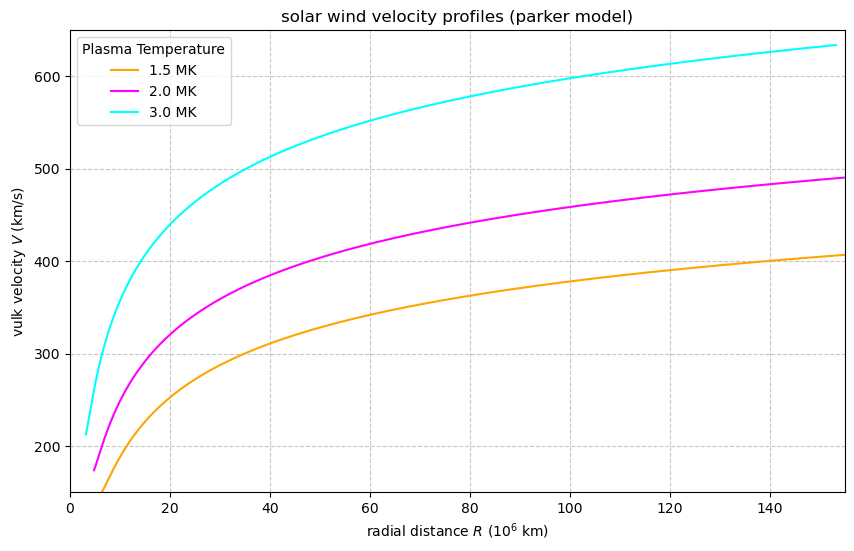

In [6]:
G=6.674e-11  
M=1.989e30   
kB=1.38e-23  
m=1.67e-27   
dr=1e7       
steps=15000  
temps=[1.5e6,2.0e6,3.0e6]
colors=['orange','magenta','cyan']  
labels=['1.5 MK','2.0 MK','3.0 MK']
plt.figure(figsize=(10, 6))
for T,color,label in zip(temps,colors,labels):
    vc=np.sqrt(kB*T/m)   
    rc=(G*M)/(2*vc**2) 
    r=np.zeros(steps)
    v=np.zeros(steps)
    r[0]=1.2*rc
    v[0]=1.35*vc
    for i in range(steps-1):
        numerator=(v[i]/r[i])*((2*kB*T/m)-(G*M/r[i]))
        denominator=v[i]**2-(kB*T/m)
        dv_dr=numerator/denominator
        v[i+1]=v[i]+dv_dr*dr
        r[i+1]=r[i]+dr
    plt.plot(r/1e9,v/1000,color=color,label=label)
plt.title("solar wind velocity profiles (parker model)")
plt.xlabel("radial distance $R$ ($10^6$ km)")
plt.ylabel("vulk velocity $V$ (km/s)")
plt.legend(title="Plasma Temperature")
plt.grid(True,linestyle='--',alpha=0.7)
plt.xlim(0,155)
plt.ylim(150,650)
plt.show()

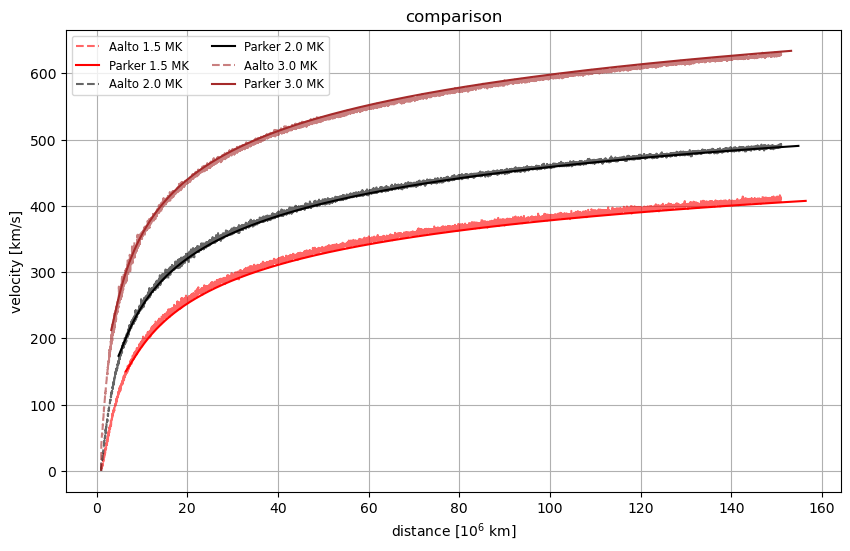

In [10]:
aalto_files=['data_SW_No1.dat','data_SW_No2.dat','data_SW_No3.dat']
colors=['red','black','brown']
plt.figure(figsize=(10, 6))
for i,T in enumerate(temps):
    data=np.loadtxt(aalto_files[i])
    plt.plot(data[:, 0]/1e9,data[:, 1]/1000,color=colors[i],linestyle='--',alpha=0.6,label=f'Aalto {T/1e6} MK')
    vc=np.sqrt(kB*T/ m)
    rc=(G*M)/(2*vc**2)
    r,v=np.zeros(steps),np.zeros(steps)
    r[0],v[0]=1.2*rc,1.35*vc
    for j in range(steps - 1):
        dv_dr=((v[j]/r[j])*((2*kB*T/m)-(G*M/r[j])))/(v[j]**2-(kB*T/m))
        v[j+1]=v[j]+dv_dr*dr
        r[j+1]=r[j]+dr
    plt.plot(r/1e9,v/1000,color=colors[i],linestyle='-',label=f'Parker {T/1e6} MK')
plt.xlabel("distance [$10^6$ km]")
plt.ylabel("velocity [km/s]")
plt.title("comparison")
plt.legend(ncol=2,fontsize='small')
plt.grid(True)
plt.show()

density at 1AU (1.5 MK): 12.45 cm^-3
density at 1AU (2.0 MK): 6.86 cm^-3
density at 1AU (3.0 MK): 2.95 cm^-3


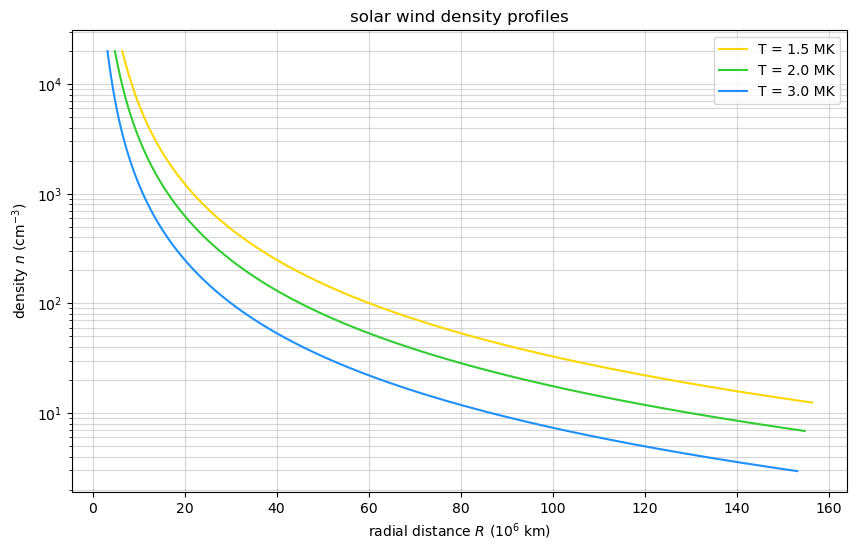

In [13]:
plt.figure(figsize=(10,6))
for T,color in zip(temps,colors):
    vc=np.sqrt(kB*T/m)
    rc=(G*M)/(2*vc**2)
    r=np.zeros(steps)
    v=np.zeros(steps)
    n=np.zeros(steps)    
    r[0]=1.2*rc
    v[0]=1.35*vc
    n[0]=n1    
    for i in range(steps-1):
        num=(v[i]/r[i])*((2*kB*T/m)-(G*M/r[i]))
        den=v[i]**2-(kB*T/m)
        dv_dr=num/den
        v[i+1]=v[i]+dv_dr*dr
        r[i+1]=r[i]+dr        
        n[i+1]=n1*(v[0]/v[i+1])*(r[0]/r[i+1])**2
    plt.plot(r/1e9,n,color=color,label=f'T = {T/1e6} MK')    
    print(f"density at 1AU ({T/1e6} MK): {n[-1]:.2f} cm^-3")
plt.yscale('log') 
plt.title("solar wind density profiles")
plt.xlabel("radial distance $R$ ($10^6$ km)")
plt.ylabel("density $n$ (cm$^{-3}$)")
plt.legend()
plt.grid(True,which="both",ls="-",alpha=0.5)
plt.show()

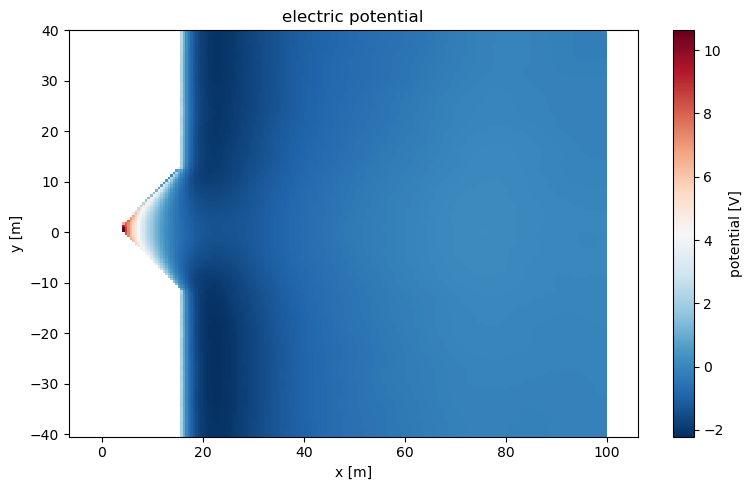

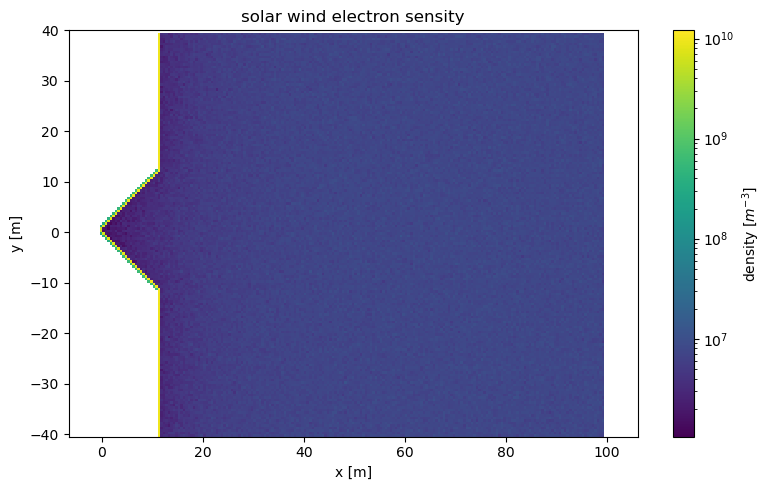

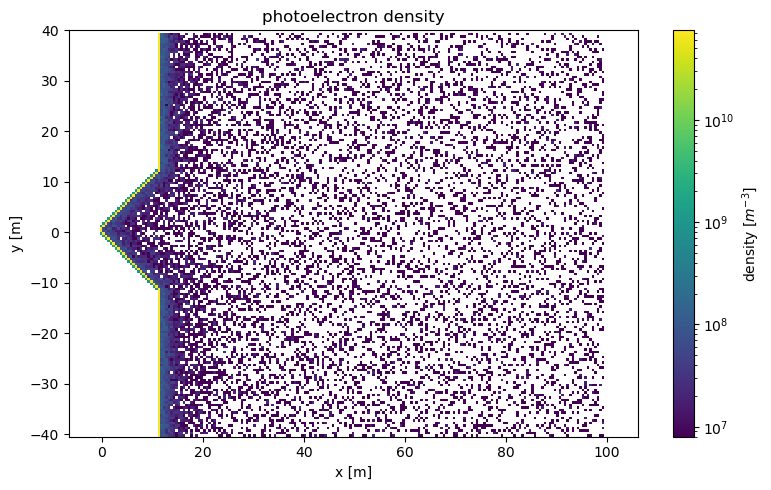

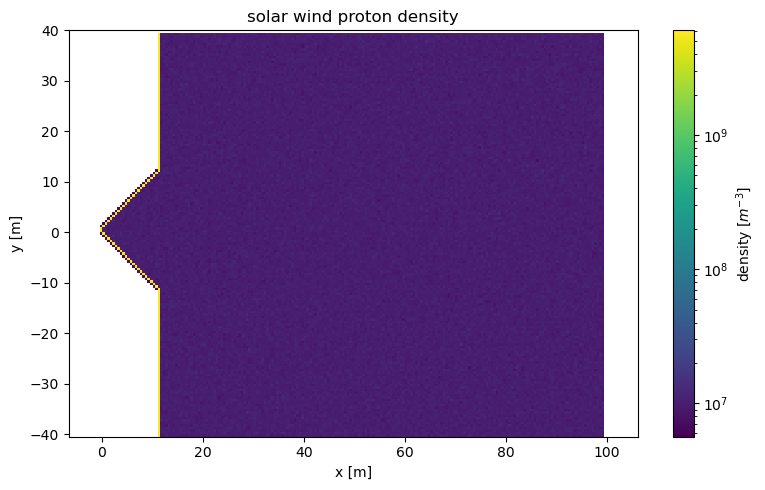

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Load the spatial grid (assumed to be 2D arrays or vectors)
x = np.loadtxt('X_map.dat')
y = np.loadtxt('Y_map.dat')

# 2. Load simulation output data
phi = np.loadtxt('PIC_2D_phi_V.txt')        # Potential (V)
ne_sw = np.loadtxt('PIC_2D_ne_SW_m3.txt')  # SW Electron Density (m^-3)
ne_moon = np.loadtxt('PIC_2D_ne_moon_m3.txt') # Photoelectron Density (m^-3)
nh = np.loadtxt('PIC_2D_nH_m3.txt')        # SW Proton Density (m^-3)

# Define plotting helper to ensure consistency
def plot_sim(data, title, label, cmap='viridis', is_log=False):
    plt.figure(figsize=(8, 5))
    norm = LogNorm() if is_log else None
    
    # Using pcolormesh for 2D spatial data
    im = plt.pcolormesh(x, y, data, cmap=cmap, norm=norm, shading='auto')
    
    plt.colorbar(im, label=label)
    plt.title(title)
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# i) Electric potential (Linear scale)
plot_sim(phi, "electric potential", "potential [V]", cmap='RdBu_r')

# ii) Solar wind electron density (Log scale)
plot_sim(ne_sw, "solar wind electron sensity", "density [$m^{-3}$]", is_log=True)

# iii) Photoelectron density (Log scale)
plot_sim(ne_moon, "photoelectron density", "density [$m^{-3}$]", is_log=True)

# iv) Solar wind proton density (Log scale)
plot_sim(nh, "solar wind proton density", "density [$m^{-3}$]", is_log=True)